In [10]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from scipy.stats import t
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import weibull_min
import plotly.graph_objects as go

from models import MultiDimPHVAE, elbo_phvae_multidim, train_phvae
from utils import *

/home/hakimmics/myenv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


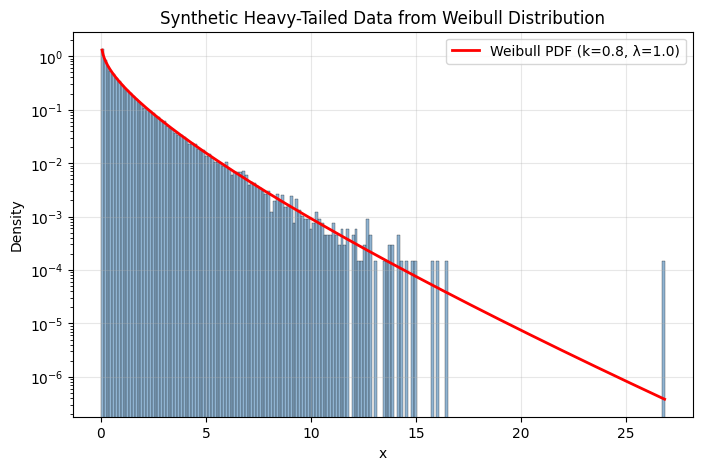

In [5]:
# weibull data
# parameters
shape_k = 0.8   
scale_lambda = 1.0  

n_samples = 50_000
data = weibull_min.rvs(shape_k, scale=scale_lambda, size=n_samples)

# Plot histogram and KDE
plt.figure(figsize=(8, 5))
sns.histplot(data, bins=200,  stat="density", color="steelblue", alpha=0.6)

# Plot the true pdf
x = np.linspace(0, data.max(), 500)
pdf = weibull_min.pdf(x, shape_k, scale=scale_lambda)
plt.plot(x, pdf, 'r-', lw=2, label=f'Weibull PDF (k={shape_k}, λ={scale_lambda})')

plt.title("Synthetic Heavy-Tailed Data from Weibull Distribution")
plt.xlabel("x")
plt.yscale('log')
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

tensor_x_w = torch.tensor(data, dtype=torch.float32).view(-1, 1)
dataset_w = TensorDataset(tensor_x_w)
train_loader_weibull = DataLoader(dataset_w, batch_size=256, shuffle=True)

# saving data 
torch.save(tensor_x_w, "data/weibull_data.pt")

In [8]:
model_weibull = MultiDimPHVAE(input_dim=1, latent_dim=10, n_phases=8)
train_phvae(
    model_weibull,
    train_loader_weibull,
    epochs=13,
    learning_rate=1e-2,
   
)

Using device: cpu


Epoch 1/13:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 001 | Loss: 1.1784 | Recon: -1.0922 | KL: 0.0862 | Time/epoch: 1.24s


Epoch 2/13:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 002 | Loss: 1.0840 | Recon: -1.0833 | KL: 0.0006 | Time/epoch: 1.10s


...

Epoch 12/13:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 012 | Loss: 1.0808 | Recon: -1.0808 | KL: 0.0000 | Time/epoch: 1.31s


Epoch 13/13:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 013 | Loss: 1.0810 | Recon: -1.0809 | KL: 0.0000 | Time/epoch: 1.12s

Total training time: 15.55s (1.20s/epoch avg)
Mean time/epoch: 1.20 ± 0.09 s


{'focus_metric': [1.0921709124946595,
  1.0833183093643188,
  1.0822185705184937,
  1.0817216504096985,
  1.0809040451812744,
  1.0812464266967774,
  1.0810988807678223,
  1.0810402913284303,
  1.081097364845276,
  1.0807788164520264,
  1.0808600925064087,
  1.0807520463180542,
  1.0809488073539735],
 'epoch_times': tensor([1.2450, 1.0997, 1.1550, 1.0363, 1.1688, 1.1933, 1.2205, 1.4126, 1.2311,
         1.2065, 1.1470, 1.3140, 1.1230])}

/home/hakimmics/myenv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


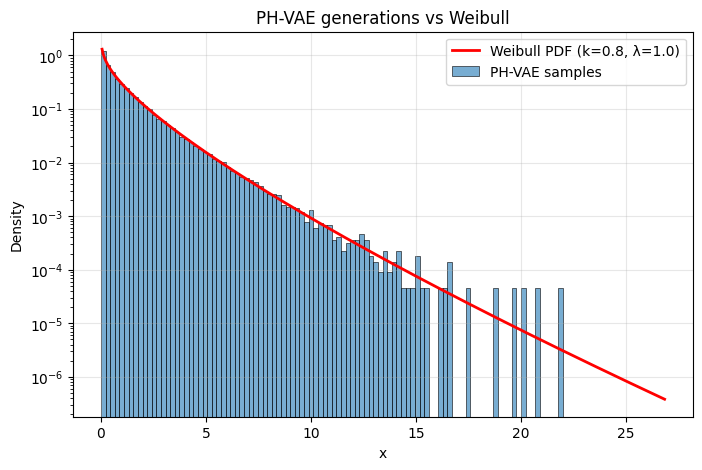

In [16]:
model_weibull.eval()
N = 100_000
device = next(model_weibull.parameters()).device
with torch.no_grad():
    # sample latents
    z = torch.randn(N, model_weibull.latent_dim, device=device)
    alpha, T, t = model_weibull.decode_params(z) 
    ph_samples  = ph_sample_multidim(alpha, T, t).cpu().numpy()
# Compare to original Weibull data
x_grid = np.linspace(0, max(ph_samples.max(), data.max()), 500)
pdf_weib = weibull_min.pdf(x_grid, shape_k, scale=scale_lambda)
plt.figure(figsize=(8,5))
sns.histplot(ph_samples, bins=100, stat="density", alpha=0.6, label="PH-VAE samples")
plt.plot(x_grid, pdf_weib, 'r-', lw=2, label=f"Weibull PDF (k={shape_k}, λ={scale_lambda})")
plt.title("PH-VAE generations vs Weibull")
plt.xlabel("x")
plt.yscale("log")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# save the model 
torch.save(model_weibull.state_dict(), "models/saved/phvae_weibull.pt")